In [1]:
import json
import re
from pathlib import Path

eval_dir = Path("../outputs/eval")
pattern = re.compile(r"act_(dinov2-base|siglip-base-patch16-224)_libero_task\d+")

results = {}
for subdir in sorted(eval_dir.iterdir()):
    if subdir.is_dir() and pattern.fullmatch(subdir.name):
        info_file = subdir / "eval_info.json"
        if info_file.exists():
            data = json.loads(info_file.read_text())
            results[subdir.name] = data["overall"]["pc_success"]

for name, success in results.items():
    print(f"{name}: {success}%")

act_dinov2-base_libero_task0: 13.0%
act_dinov2-base_libero_task1: 62.0%
act_dinov2-base_libero_task2: 41.0%
act_dinov2-base_libero_task3: 70.0%
act_siglip-base-patch16-224_libero_task0: 25.0%
act_siglip-base-patch16-224_libero_task1: 49.0%
act_siglip-base-patch16-224_libero_task2: 39.0%
act_siglip-base-patch16-224_libero_task3: 37.0%


In [33]:
import json
import re
from pathlib import Path
import pandas as pd

eval_dir = Path("../outputs/eval")
pattern = re.compile(r"act_(dinov2-base|siglip-base-patch16-224)_libero_task(\d+)(_bblr[a-zA-Z0-9.+-]+)?(_unfrozen)?")

rows = []
for subdir in sorted(eval_dir.iterdir()):
    m = pattern.fullmatch(subdir.name)
    if not (subdir.is_dir() and m):
        continue
    encoder = m.group(1)
    task = int(m.group(2))
    bblr = m.group(3)[len("_bblr"):] if m.group(3) else 1e-5
    frozen = m.group(4) is None  # no "_unfrozen" suffix means encoder is frozen

    def add_row(info_file, step):
        if info_file.exists():
            data = json.loads(info_file.read_text())
            rows.append({
                "encoder": encoder,
                "task": task,
                "frozen": frozen,
                "bblr": bblr,
                "step": step,
                "pc_success": data["overall"]["pc_success"],
            })

    add_row(subdir / "eval_info.json", step=None)
    for step_dir in sorted(subdir.iterdir()):
        if step_dir.is_dir() and step_dir.name.isdigit():
            add_row(step_dir / "eval_info.json", step=int(step_dir.name))

df = pd.DataFrame(rows).sort_values(["encoder", "frozen", "bblr", "task", "step"]).reset_index(drop=True)
# df.fillna(100000, inplace=True)
df[df['bblr'] == '1e-6_unfrozen']

,encoder,task,frozen,bblr,step,pc_success


In [34]:
df['bblr'].unique()

array([1e-05, '1e-6'], dtype=object)

(<Figure size 1000x800 with 4 Axes>,
 array([[<Axes: title={'center': '0'}, xlabel='Environment Frames', ylabel='Evaluation Return'>,
         <Axes: title={'center': '1'}, xlabel='Environment Frames'>],
        [<Axes: title={'center': '2'}, xlabel='Environment Frames', ylabel='Evaluation Return'>,
         <Axes: title={'center': '3'}, xlabel='Environment Frames'>]],
       dtype=object))

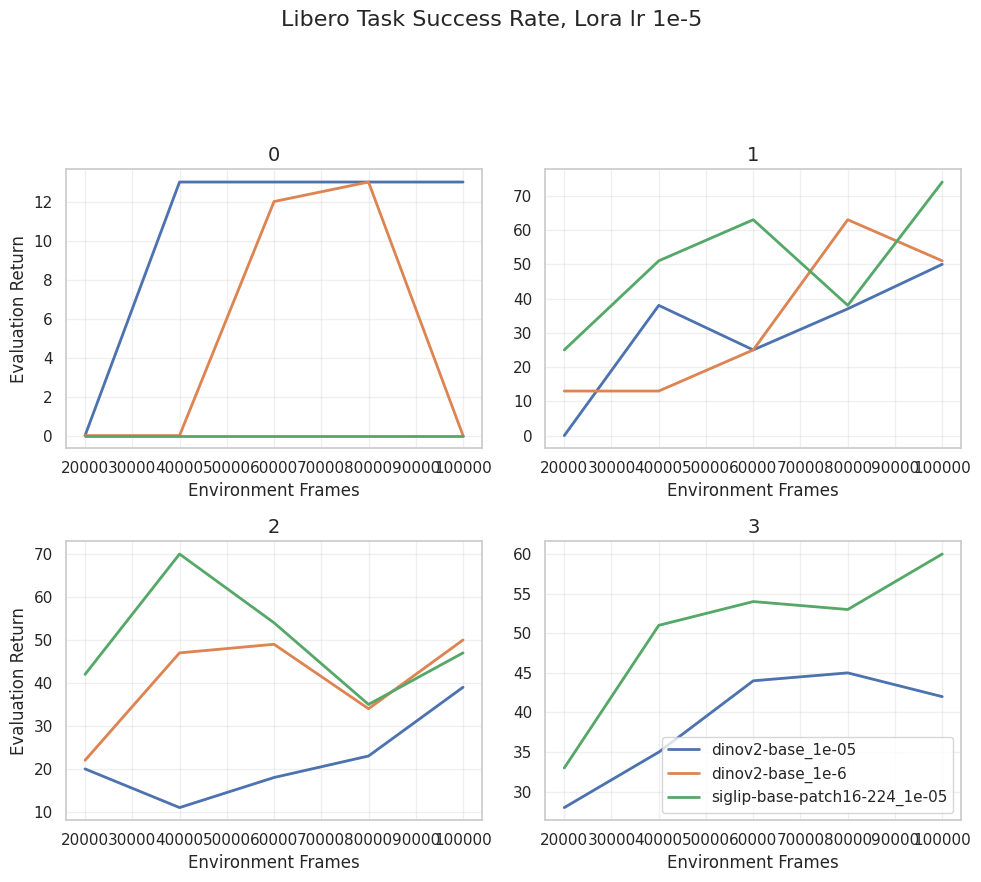

In [35]:
from rlplot import plot_training_curves

plot_training_curves(
    df[df['frozen'] == False],
    task_col='task',
    algo_col=['encoder', 'bblr'],
    step_col="step",
    value_col="pc_success",
    algo_style=None,
    spread="sem",
    figsize_per_task=(5, 4),
    nrow=2,
    suptitle="Libero Task Success Rate, Lora lr 1e-5",
    legend_loc="last_ax",
)

In [1]:
import json
import re
from pathlib import Path

eval_dir = Path("../outputs/eval")
pattern = re.compile(r"act_(dinov2-base|siglip-base-patch16-224)_libero_task\d+_unfrozen")

results = {}
for subdir in sorted(eval_dir.iterdir()):
    if subdir.is_dir() and pattern.fullmatch(subdir.name):
        info_file = subdir / "eval_info.json"
        if info_file.exists():
            data = json.loads(info_file.read_text())
            results[subdir.name] = data["overall"]["pc_success"]

for name, success in results.items():
    print(f"{name}: {success}%")

act_dinov2-base_libero_task0_unfrozen: 13.0%
act_dinov2-base_libero_task1_unfrozen: 25.0%
act_dinov2-base_libero_task2_unfrozen: 18.0%
act_dinov2-base_libero_task3_unfrozen: 44.0%
act_siglip-base-patch16-224_libero_task0_unfrozen: 0.0%
act_siglip-base-patch16-224_libero_task1_unfrozen: 74.0%
act_siglip-base-patch16-224_libero_task2_unfrozen: 47.0%
act_siglip-base-patch16-224_libero_task3_unfrozen: 60.0%


In [3]:
list(eval_dir.iterdir()
)

[PosixPath('../outputs/eval/act_dinov2-base_libero_task1'),
 PosixPath('../outputs/eval/act_dinov2-base_libero_task3_unfrozen'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task3_unfrozen'),
 PosixPath('../outputs/eval/act_dinov2-base_libero_task0_unfrozen'),
 PosixPath('../outputs/eval/act_dinov2-base_libero_task3'),
 PosixPath('../outputs/eval/2026-02-06'),
 PosixPath('../outputs/eval/act_libero_task0_bs16_lr5e-4'),
 PosixPath('../outputs/eval/act_dinov2-base_libero_task0'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task0_unfrozen'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task0'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task3'),
 PosixPath('../outputs/eval/act_dinov2-base_libero_task2'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task1'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_libero_task2_unfrozen'),
 PosixPath('../outputs/eval/act_siglip-base-patch16-224_liber